In [12]:
%pip install supabase

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 27.7 MB/s  0:00:00
   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   ---------------------------------------- 3.8/3.8 MB 43.6 MB/s  0:00:00

   -- -------------------------------------  2/29 [typing-inspection]
   --------- ------------------------------  7/29 [multidict]
   ----------------- ---------------------- 13/29 [certifi]
   ---------------------- ----------------- 16/29 [pydantic]
   ---------------------- ----------------- 16/29 [pydantic]
   ----------------------- ---------------- 17/29 [httpcore]
   --------------------------- ------------ 20/29 [anyio]
   ---------------------------- ----------- 21/29 [realtime]
   ------------------------------- -------- 23/29 [cryptography]
   ------------------------------- -------- 23/29 [cryptography]
   ------------------------------------- -- 27/29 [postgrest]
   ------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [18]:
import pandas as pd
from supabase import create_client, Client

# 1. Configurar las llaves de acceso
url = "https://ixxwynbvjymnqhmywxwh.supabase.co"
key = "sb_publishable_qbIqSSxQvLB9AFlqv93bmA_rO4dga4t"
supabase: Client = create_client(url, key)

print("Intentando conectar a la nube de Supabase...")

# 2. Descargar la tabla completa (Capa Silver)
respuesta = supabase.table("default_credit_card_clients").select("*").execute()

# 3. Convertirla en un DataFrame (tabla de Python)
df_model = pd.DataFrame(respuesta.data)

print(f"Éxito total! Somos lo máximo, se descargaron {df_model.shape[0]} filas y {df_model.shape[1]} columnas desde la nube.")
display(df_model.head(3))

Intentando conectar a la nube de Supabase...
Éxito total! Somos lo máximo, se descargaron 33377 filas y 30 columnas desde la nube.


,bronze_record_id,source_type,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,...,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,record_origin,source_parent_id,raw_quality_flags
0,1,uci_public,1,20000.0,2,2,1,24.0,2,2,...,0.0,689.0,0.0,0.0,0.0,0.0,1,public_original,1,NaN
1,2,uci_public,2,120000.0,2,2,2,26.0,-1,2,...,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,public_original,2,NaN
2,3,uci_public,3,90000.0,2,2,2,34.0,0,0,...,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,public_original,3,NaN


In [20]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.4 MB 12.0 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.4 MB 19.5 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 23.1 MB/s  0:00:00
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   -------------- ------------------------- 13.4/37.4 MB 63.5 MB/s eta 0:00:01
   ------------------------- -------------- 24.1/37.4 MB 63.2 MB/s eta 0:00:01
   ----------------------------------- ---- 33.0/37.4 MB 53.6 MB/s eta 0:00:01
   ---------------------------------------- 37.4/37.4 MB 47.4 MB/s  0:00:00

   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ -----------------------------

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Preparando los datos para el modelo (Capa Gold)...")

# 1. Separar características (X) y la variable a predecir (y)
# Eliminamos las columnas de metadatos que no sirven para predecir
columnas_admin = ["bronze_record_id", "source_type", "ID", "record_origin", "source_parent_id", "raw_quality_flags"]
columnas_a_borrar = [col for col in columnas_admin if col in df_model.columns]

X = df_model.drop(columns=columnas_a_borrar + ["default payment next month"])
y = df_model["default payment next month"]

# 2. Dividir la data: 80% para que la IA estudie, 20% para tomarle un examen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Crear y entrenar el motor predictivo (Random Forest)
print("Entrenando el algoritmo de Inteligencia Artificial. Esto puede tomar unos segundos, será rápido gente...")
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

# 4. Hacer predicciones y evaluar
predicciones = modelo_rf.predict(X_test)
precision = accuracy_score(y_test, predicciones)

print("\n¡Modelo entrenado exitosamente!")
print(f"Precisión global del modelo: {precision * 100:.2f}%")

Preparando los datos para el modelo (Capa Gold)...
Entrenando el algoritmo de Inteligencia Artificial. Esto puede tomar unos segundos, será rápido gente...

¡Modelo entrenado exitosamente!
Precisión global del modelo: 83.07%


In [24]:
import joblib

# Definimos el nombre del archivo donde vivirá el modelo
nombre_archivo = 'modelo_riesgo_crediticio.pkl'

# Guardamos el modelo ("modelo_rf") en el disco duro
joblib.dump(modelo_rf, nombre_archivo)

print(f"¡Cerebro respaldado con éxito! Tu Inteligencia Artificial se guardó en el archivo: '{nombre_archivo}'.")

¡Cerebro respaldado con éxito! Tu Inteligencia Artificial se guardó en el archivo: 'modelo_riesgo_crediticio.pkl'.


In [28]:
print("Simulacion de prediccion para un cliente de prueba")
print("--------------------------------------------------")

# Seleccionamos un cliente al azar de nuestros datos de prueba (fila 15)
cliente_prueba = X_test.iloc[[15]]

# Hacemos que el modelo evalue el historial de este cliente
prediccion = modelo_rf.predict(cliente_prueba)

print("\nConclusion del modelo:")
if prediccion[0] == 1:
    print("Cliente con alto riesgo de morosidad - Sugerencia: Rechazar credito")
else:
    print("Cliente con buen perfil de pago - Sugerencia: Aprobar credito, dale no más.")

Simulacion de prediccion para un cliente de prueba
--------------------------------------------------

Conclusion del modelo:
Cliente con buen perfil de pago - Sugerencia: Aprobar credito, dale no más.


Generando grafico de variables...


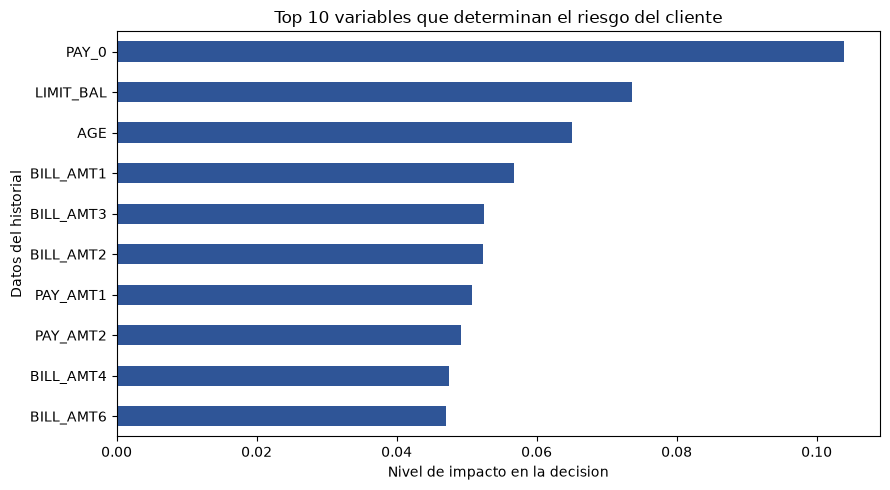

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

print("Generando grafico de variables...")

# Extraemos el peso que el algoritmo le dio a cada columna
importancias = modelo_rf.feature_importances_

# Emparejamos los nombres de las variables con su respectivo peso
pesos_variables = pd.Series(importancias, index=X_test.columns)

# Ordenamos los datos y sacamos solo las 10 mas importantes
top_10 = pesos_variables.sort_values(ascending=True).tail(10)

# Dibujamos el grafico con un diseno limpio
plt.figure(figsize=(9, 5))
top_10.plot(kind='barh', color='#2f5597') # Color azul sobrio
plt.title('Top 10 variables que determinan el riesgo del cliente')
plt.xlabel('Nivel de impacto en la decision')
plt.ylabel('Datos del historial')
plt.tight_layout()
plt.show()